In [1]:
# CONFIGURATION
# =============
# Add/remove LLMs here.
LLMS = [
    {'name': 'DeepSeek-R1-Distill-Llama-8B', 'pretty': 'DeepSeek-R1-Distill-Llama-8B', 'num_layers': 32},
    {'name': 'DeepSeek-R1-Distill-Qwen-7B',  'pretty': 'DeepSeek-R1-Distill-Qwen-7B',  'num_layers': 28},
    {'name': 'Llama-2-7b-hf',                'pretty': 'Llama-2-7b-hf',                'num_layers': 32},
    {'name': 'Llama-3.1-8B-Instruct',        'pretty': 'Llama-3.1-8B-Instruct',        'num_layers': 32},
    {'name': 'Mistral-7B-v0.1',              'pretty': 'Mistral-7B-v0.1',              'num_layers': 32},
    {'name': 'OLMo-2-1124-7B-Instruct',      'pretty': 'OLMo-2-1124-7B-Instruct',      'num_layers': 32},
    {'name': 'Qwen3-8B',                     'pretty': 'Qwen3-8B',                     'num_layers': 36},
]

# Specify the probing setting
PROBE_SETTING = 'int_sci_compare'  # e.g., 'dec_dec_compare', 'int_sci_compare'

# Offsets for each probe type
OFFSET_REGRESSION = 'mixed_offset_0'       # e.g., 'mixed_offset_0', 'int_offset_0', 'sci_offset_0' for int-sci comparison
OFFSET_CLASSIFICATION = 'last_token'       # e.g., 'last_token', 'concat_offset_0'
OFFSET_REGRESSION_DIFF = 'last_token'      # e.g., 'last_token', 'concat_offset_0'

# Where to save figures
SAVE_FIG_PATH = '../figures/'

# Which split to use
SPLIT = 'val'

# Which verbalization setting to use (should match PROBE_SETTING)
VERBALIZATION_SETTING = PROBE_SETTING


In [2]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# Create save directory
os.makedirs(SAVE_FIG_PATH, exist_ok=True)
os.makedirs(os.path.join(SAVE_FIG_PATH, "layerwise", PROBE_SETTING), exist_ok=True)
os.makedirs(os.path.join(SAVE_FIG_PATH, "correlation", PROBE_SETTING), exist_ok=True)

def get_probe_results(llm, probe_setting, probe_type, offset, split):
    """Load probe results for a given LLM and setting."""
    base = f'../results/{llm}/{probe_setting}/{probe_type}'
    path = os.path.join(base, offset, f'{split}_results.json')

    if not os.path.exists(path):
        print(f'Warning: {path} not found!')
        return None
    
    with open(path, 'r') as f:
        data = json.load(f)
    return data

def get_verbalization_acc(llm, setting):
    """Load verbalization accuracy for a given LLM and setting."""
    path = f'../verbalization-test/{llm}/{setting}.jsonl'
    if not os.path.exists(path):
        print(f'Warning: {path} not found!')
        return None
    
    with open(path, 'r') as f:
        first_line = f.readline()
        if not first_line.strip():
            return None
        result = json.loads(first_line)
    return result.get('overall_accuracy', None)

In [3]:
# Load all results
regression_probe_results = {}
classification_probe_results = {}
regression_diff_probe_results = {}
verbalization_accs = {}

for llm in LLMS:
    name = llm['name']
    regression_probe_results[name] = get_probe_results(name, PROBE_SETTING, "regression", OFFSET_REGRESSION, SPLIT)
    classification_probe_results[name] = get_probe_results(name, PROBE_SETTING, "classification", OFFSET_CLASSIFICATION, SPLIT)
    regression_diff_probe_results[name] = get_probe_results(name, PROBE_SETTING, "regression_diff", OFFSET_REGRESSION_DIFF, SPLIT)
    verbalization_accs[name] = get_verbalization_acc(name, VERBALIZATION_SETTING)

print('Loaded LLMs:', list(regression_probe_results.keys()))
print('\nVerbalization Accuracies:')
for name, acc in verbalization_accs.items():
    print(f'  {name}: {acc}')


Loaded LLMs: ['DeepSeek-R1-Distill-Llama-8B', 'DeepSeek-R1-Distill-Qwen-7B', 'Llama-2-7b-hf', 'Llama-3.1-8B-Instruct', 'Mistral-7B-v0.1', 'OLMo-2-1124-7B-Instruct', 'Qwen3-8B']

Verbalization Accuracies:
  DeepSeek-R1-Distill-Llama-8B: 0.578125
  DeepSeek-R1-Distill-Qwen-7B: 0.641875
  Llama-2-7b-hf: 0.508125
  Llama-3.1-8B-Instruct: 0.550625
  Mistral-7B-v0.1: 0.5
  OLMo-2-1124-7B-Instruct: 0.534375
  Qwen3-8B: 0.7


## 1. Regression Analysis

### 1.1 Plot layer-wise metrics for regression probes

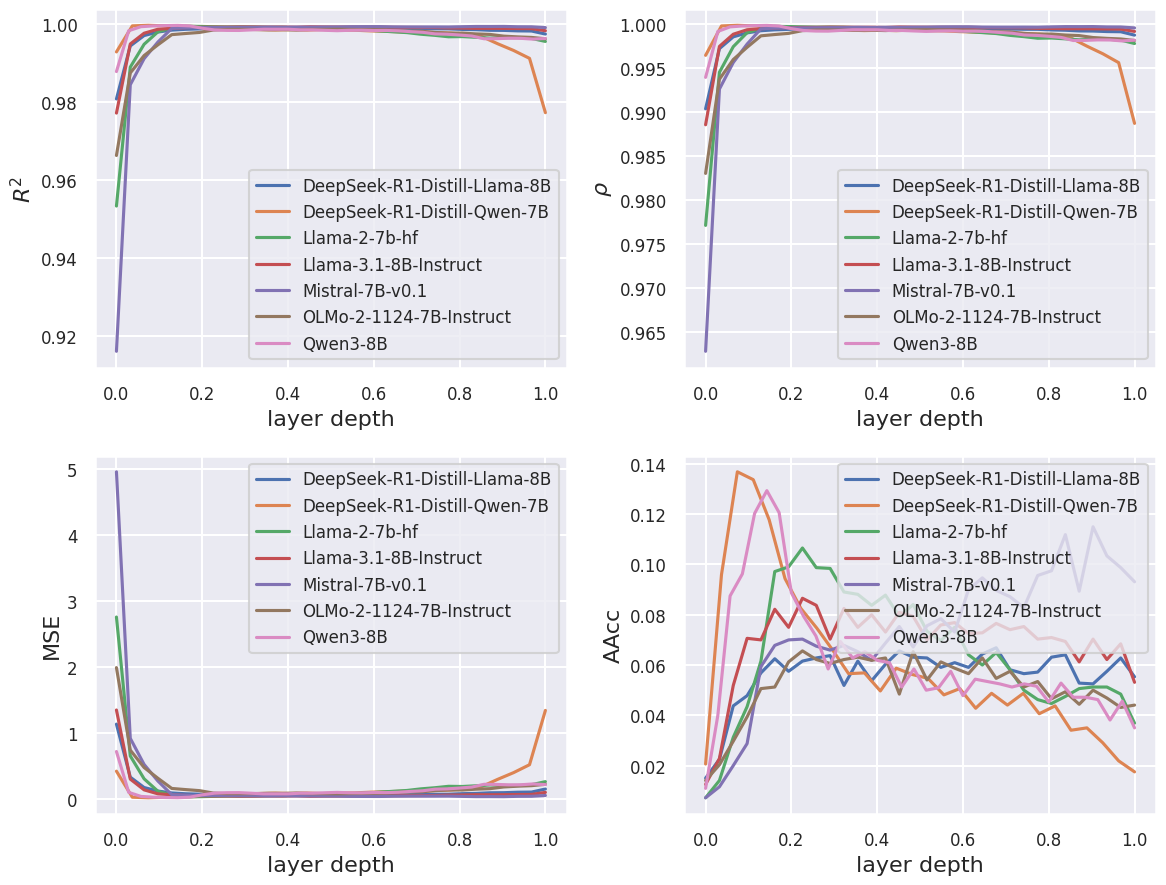

In [4]:
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

REGRESSION_METRICS = [f'{SPLIT}_{metric}' for metric in ['r2', 'pearson', 'mse', 'acc_1%']]
REGRESSION_METRIC_TITLES = [r'$R^2$', r'$\rho$', 'MSE', 'AAcc']

sns.set_theme(style="darkgrid", context="talk")
mpl.rcParams['lines.markersize'] = 4
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, metric in enumerate(REGRESSION_METRICS):
    ax = axes[i]

    for llm in LLMS:
        name = llm['name']
        pretty = llm['pretty']
        num_layers = llm['num_layers']
        data = regression_probe_results[name]

        if data is None:
            continue

        layers = range(num_layers)
        norm_layers = [i / (num_layers - 1) for i in layers]
        values = [data[layer][metric] for layer in layers]

        sns.lineplot(x=norm_layers[:len(values)],
                     y=values,
                     label=pretty,
                     ax=ax)

    ax.set_xlabel('layer depth')
    ax.set_ylabel(REGRESSION_METRIC_TITLES[i])
    ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(os.path.join(SAVE_FIG_PATH, "layerwise", PROBE_SETTING, f'regression_{OFFSET_REGRESSION}.pdf'),
            dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(SAVE_FIG_PATH, "layerwise", PROBE_SETTING, f'regression_{OFFSET_REGRESSION}.png'),
            dpi=300, bbox_inches='tight')
plt.show()


Probe Metrics Across Layers: int_sci_compare (regression, mixed_offset_0)


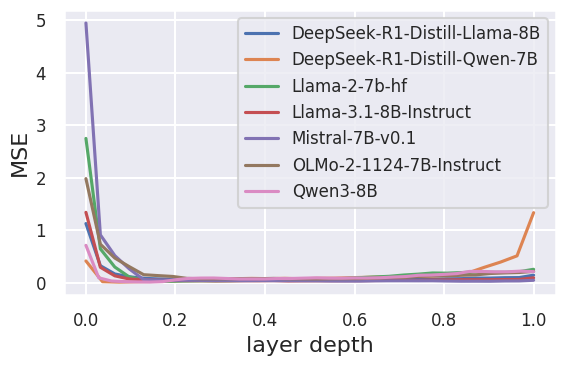

In [5]:
# Plot layer-wise MSE for regression probes
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

mpl.rcParams['lines.markersize'] = 2
plt.figure(figsize=(6, 4))

metric = 'val_mse'
sns.set_style("darkgrid")
for llm in LLMS:
    name = llm['name']
    pretty = llm['pretty']
    num_layers = llm['num_layers']
    data = regression_probe_results[name]
    
    if data is None:
        continue
        
    layers = range(num_layers)
    norm_layers = [i / (num_layers - 1) for i in layers]
    values = [data[layer][metric] for layer in layers]
    

    sns.lineplot(x=norm_layers[:len(values)],
                 y=values,
                 label=pretty)
    # save the subplot

    plt.xlabel('layer depth')
    plt.ylabel('MSE')
    plt.legend()

print(f'Probe Metrics Across Layers: {PROBE_SETTING} (regression, {OFFSET_REGRESSION})')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_FIG_PATH, "layerwise", PROBE_SETTING, f'regression_{OFFSET_REGRESSION}_mse.pdf'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(SAVE_FIG_PATH, "layerwise", PROBE_SETTING, f'regression_{OFFSET_REGRESSION}_mse.png'), dpi=300, bbox_inches='tight')
plt.show()


### 1.2 Regression correlation: verbalization accuracy vs. probe metrics (max/mean/first/mean first 3/last)


Correlation: Verbalization Acc vs. Mean_first_3 Probe Metrics: int_sci_compare (regression, mixed_offset_0)


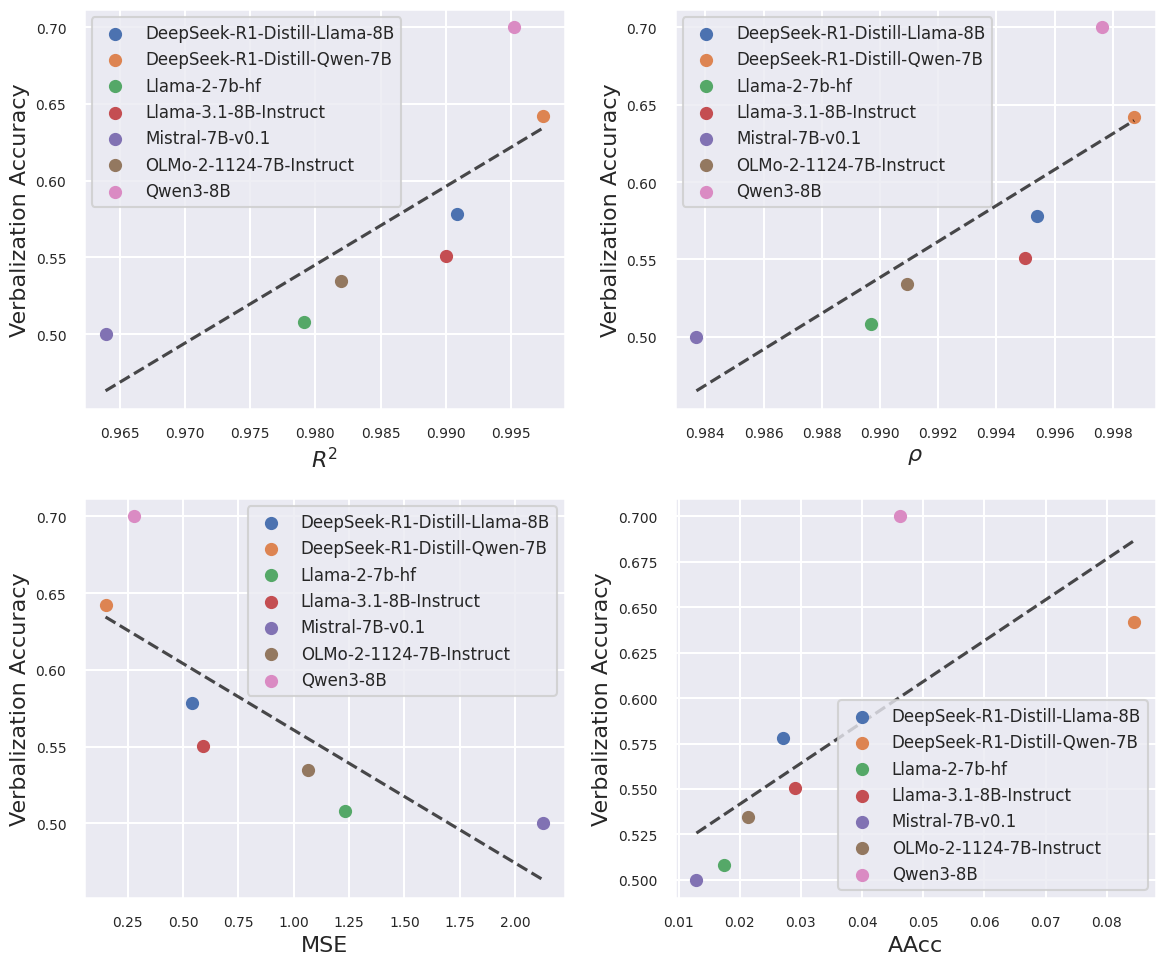

In [6]:
# summary_types = ['max', 'mean', 'first', 'mean_first_3', 'last']
summary_types = ['mean_first_3']
REGRESSION_METRICS = [f'{SPLIT}_{metric}' for metric in ['r2', 'pearson', 'mse', 'acc_1%']]
REGRESSION_METRIC_TITLES = [r'$R^2$', r'$\rho$', 'MSE', 'AAcc']

sns.set_theme(style="darkgrid", context="talk")
mpl.rcParams['lines.markersize'] = 8
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 10
for summary_type in summary_types:
    plt.figure(figsize=(12, 10))
    
    for i, metric in enumerate(REGRESSION_METRICS):
        plt.subplot(2, 2, i+1)
        x_data, y_data, labels = [], [], []
        
        for llm in LLMS:
            name = llm['name']
            pretty = llm['pretty']
            num_layers = llm['num_layers']
            data = regression_probe_results[name]
            v_acc = verbalization_accs[name]
            
            if data is None or v_acc is None:
                continue
                
            values = [data[layer][metric] for layer in range(num_layers)]
            if not values: 
                continue
            
            # Calculate summary statistic
            if summary_type == 'max':
                val = max(values)
            elif summary_type == 'mean':
                val = np.mean(values)
            elif summary_type == 'first':
                val = values[0]
            elif summary_type == 'last':
                val = values[-1]
            elif summary_type == 'mean_first_3':
                val = np.mean(values[:3])
                
            x_data.append(val)
            y_data.append(v_acc)
            labels.append(pretty)
            plt.scatter(val, v_acc, label=pretty)
        
        if not x_data: 
            continue
        
        # Add regression line
        z = np.polyfit(x_data, y_data, 1)
        p = np.poly1d(z)
        x_range = np.linspace(min(x_data), max(x_data), 100)
        plt.plot(x_range, p(x_range), '--', color='black', alpha=0.7)

        plt.xlabel(f"{REGRESSION_METRIC_TITLES[i]}")
        plt.ylabel("Verbalization Accuracy")
        # plt.title(titles[i])
        plt.grid(True)
        plt.legend()
    
    print(f'Correlation: Verbalization Acc vs. {summary_type.capitalize()} Probe Metrics: {PROBE_SETTING} (regression, {OFFSET_REGRESSION})')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_FIG_PATH, "correlation", PROBE_SETTING, f'regression_{OFFSET_REGRESSION}_{summary_type}.pdf'), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(SAVE_FIG_PATH, "correlation", PROBE_SETTING, f'regression_{OFFSET_REGRESSION}_{summary_type}.png'), dpi=300, bbox_inches='tight')
    plt.show()


Correlation: Verbalization Acc vs. Mean_first_3 Probe Metrics: int_sci_compare (regression, mixed_offset_0)


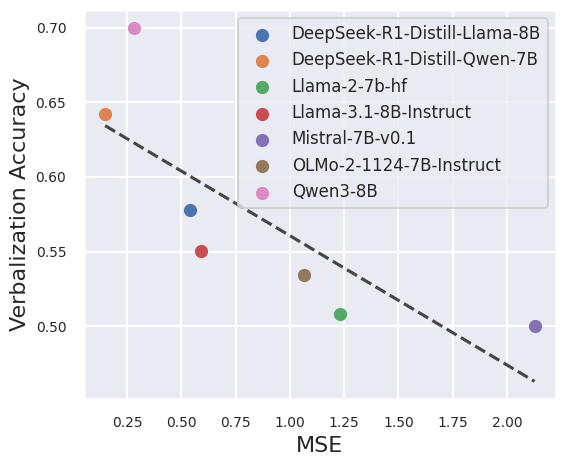

In [7]:
# Plot MSE vs. verbalization accuracy

# summary_types = ['max', 'mean', 'first', 'mean_first_3', 'last']
summary_types = ['mean_first_3']
metric = f'{SPLIT}_mse'
title = 'MSE'
sns.set_theme(style="darkgrid", context="talk")
mpl.rcParams['lines.markersize'] = 8
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 10
plt.figure(figsize=(6, 5))
x_data, y_data, labels = [], [], []

for summary_type in summary_types:
    for llm in LLMS:
        name = llm['name']
        pretty = llm['pretty']
        num_layers = llm['num_layers']
        data = regression_probe_results[name]
        v_acc = verbalization_accs[name]
        
        if data is None or v_acc is None:
            continue
            
        values = [data[layer][metric] for layer in range(num_layers)]
        if not values: 
            continue
        
        # Calculate summary statistic
        if summary_type == 'max':
            val = max(values)
        elif summary_type == 'mean':
            val = np.mean(values)
        elif summary_type == 'first':
            val = values[0]
        elif summary_type == 'last':
            val = values[-1]
        elif summary_type == 'mean_first_3':
            val = np.mean(values[:3])
            
        x_data.append(val)
        y_data.append(v_acc)
        labels.append(pretty)
        plt.scatter(val, v_acc, label=pretty)

    # Add regression line
    z = np.polyfit(x_data, y_data, 1)
    p = np.poly1d(z)
    x_range = np.linspace(min(x_data), max(x_data), 100)
    plt.plot(x_range, p(x_range), '--', color='black', alpha=0.7)

    plt.xlabel(f"{title}")
    plt.ylabel("Verbalization Accuracy")
    plt.grid(True)
    plt.legend()
        
    print(f'Correlation: Verbalization Acc vs. {summary_type.capitalize()} Probe Metrics: {PROBE_SETTING} (regression, {OFFSET_REGRESSION})')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_FIG_PATH, "correlation", PROBE_SETTING, f'regression_{OFFSET_REGRESSION}_{summary_type}_{metric}.pdf'), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(SAVE_FIG_PATH, "correlation", PROBE_SETTING, f'regression_{OFFSET_REGRESSION}_{summary_type}_{metric}.png'), dpi=300, bbox_inches='tight')
    plt.show()


## 2. Classification Analysis

### 2.1 Plot layer-wise metrics for classification probes

Probe Metrics Across Layers: int_sci_compare (classification, last_token)


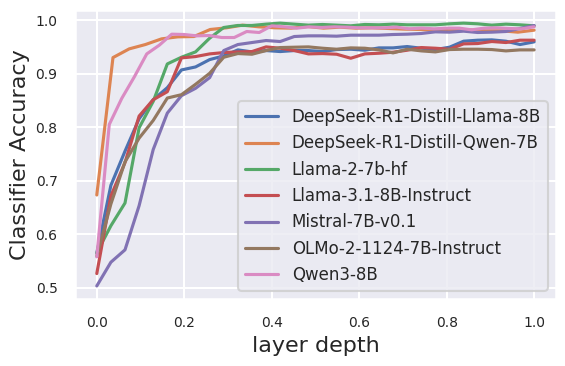

In [8]:
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

mpl.rcParams['lines.markersize'] = 2
plt.figure(figsize=(6, 4))

metric = f'{SPLIT}_acc'
sns.set_style("darkgrid")
for llm in LLMS:
    name = llm['name']
    pretty = llm['pretty']
    num_layers = llm['num_layers']
    data = classification_probe_results[name]
    
    if data is None:
        continue
        
    layers = range(num_layers)
    norm_layers = [i / (num_layers - 1) for i in layers]
    values = [data[layer][metric] for layer in layers]
    
    sns.lineplot(x=norm_layers[:len(values)],
                 y=values,
                 label=pretty)
    # save the subplot

    plt.xlabel('layer depth')
    plt.ylabel('Classifier Accuracy')
    plt.legend()

print(f'Probe Metrics Across Layers: {PROBE_SETTING} (classification, {OFFSET_CLASSIFICATION})')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_FIG_PATH, "layerwise", PROBE_SETTING, f'classification_{OFFSET_CLASSIFICATION}_acc.pdf'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(SAVE_FIG_PATH, "layerwise", PROBE_SETTING, f'classification_{OFFSET_CLASSIFICATION}_acc.png'), dpi=300, bbox_inches='tight')
plt.show()


### 2.2 Classification correlation: verbalization accuracy vs. probe metrics (max/mean/first/mean first 3/last)


Correlation: Verbalization Acc vs. Mean_first_3 Probe Metrics: int_sci_compare (classification, last_token)


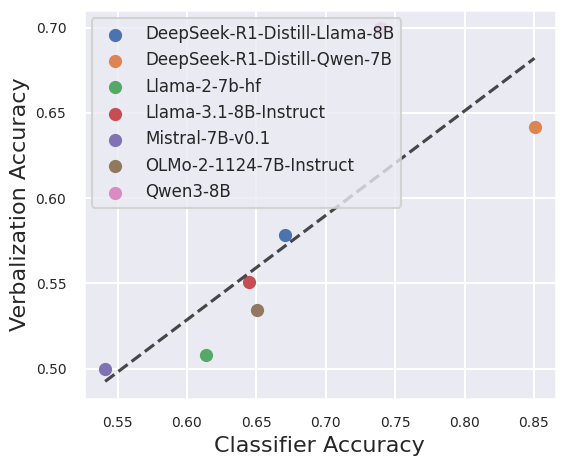

In [9]:
# summary_types = ['max', 'mean', 'first', 'mean_first_3', 'last']
summary_types = ['mean_first_3']
CLASSIFICATION_METRICS = [f'{SPLIT}_acc']
CLASSIFICATION_METRIC_TITLES = [r'Classifier Accuracy']

sns.set_theme(style="darkgrid", context="talk")
mpl.rcParams['lines.markersize'] = 8
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 10
for summary_type in summary_types:
    plt.figure(figsize=(6,5))
    
    for i, metric in enumerate(CLASSIFICATION_METRICS):
        x_data, y_data, labels = [], [], []
        
        for llm in LLMS:
            name = llm['name']
            pretty = llm['pretty']
            num_layers = llm['num_layers']
            data = classification_probe_results[name]
            v_acc = verbalization_accs[name]
            
            if data is None or v_acc is None:
                continue
                
            values = [data[layer][metric] for layer in range(num_layers)]
            if not values: 
                continue
            
            # Calculate summary statistic
            if summary_type == 'max':
                val = max(values)
            elif summary_type == 'mean':
                val = np.mean(values)
            elif summary_type == 'first':
                val = values[0]
            elif summary_type == 'last':
                val = values[-1]
            elif summary_type == 'mean_first_3':
                val = np.mean(values[:3])
                
            x_data.append(val)
            y_data.append(v_acc)
            labels.append(pretty)
            plt.scatter(val, v_acc, label=pretty)
        
        if not x_data: 
            continue
        
        # Add regression line
        z = np.polyfit(x_data, y_data, 1)
        p = np.poly1d(z)
        x_range = np.linspace(min(x_data), max(x_data), 100)
        plt.plot(x_range, p(x_range), '--', color='black', alpha=0.7)

        plt.xlabel(f"{CLASSIFICATION_METRIC_TITLES[i]}")
        plt.ylabel("Verbalization Accuracy")
        # plt.title(titles[i])
        plt.grid(True)
        plt.legend()
    
    print(f'Correlation: Verbalization Acc vs. {summary_type.capitalize()} Probe Metrics: {PROBE_SETTING} (classification, {OFFSET_CLASSIFICATION})')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_FIG_PATH, "correlation", PROBE_SETTING, f'classification_{OFFSET_CLASSIFICATION}_{summary_type}.pdf'), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(SAVE_FIG_PATH, "correlation", PROBE_SETTING, f'classification_{OFFSET_CLASSIFICATION}_{summary_type}.png'), dpi=300, bbox_inches='tight')
    plt.show()


# 3. Log-ratio Regression Analysis


### 3.1 Plot layer-wise metrics for log-ratio regression probes


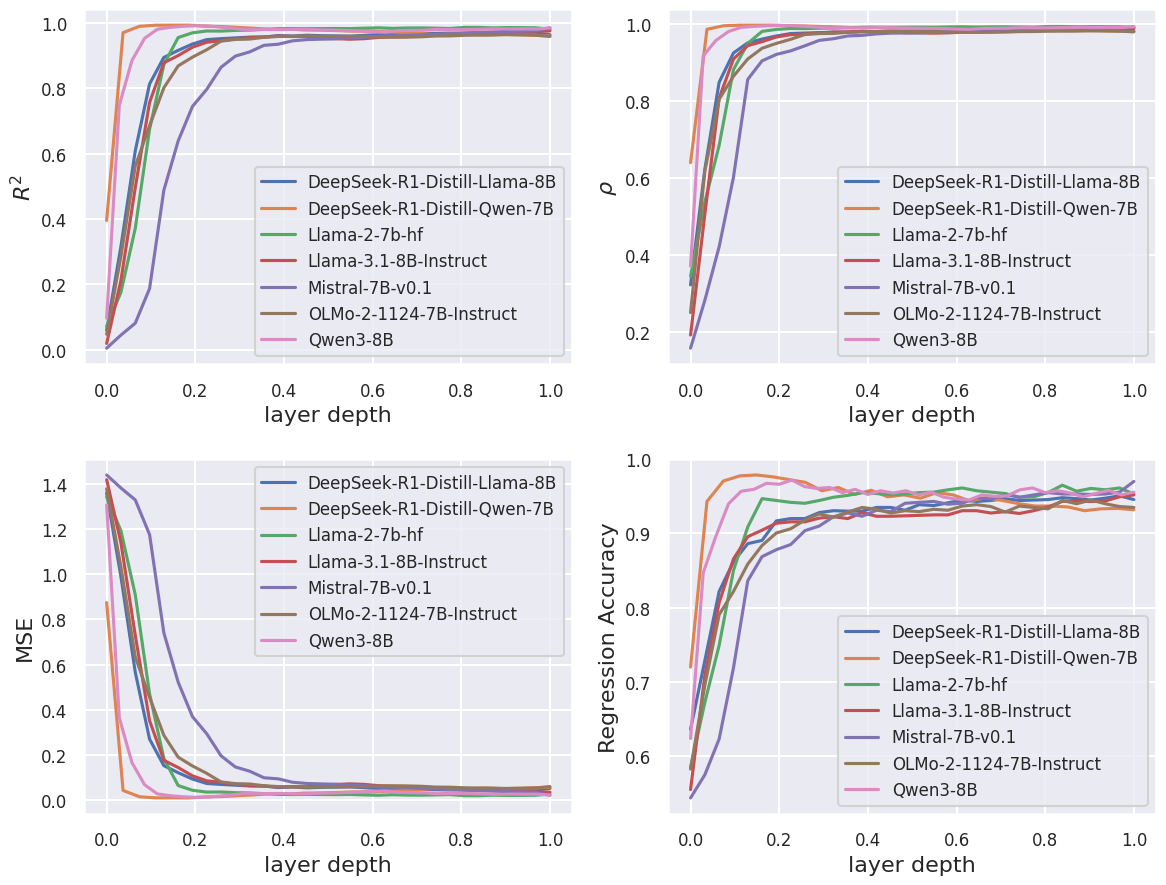

In [10]:
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

LOG_RATIO_REGRESSION_METRICS = [f'{SPLIT}_{metric}' for metric in ['r2', 'pearson', 'mse', 'acc']]
LOG_RATIO_REGRESSION_METRIC_TITLES = [r'$R^2$', r'$\rho$', 'MSE', 'Regression Accuracy']

sns.set_theme(style="darkgrid", context="talk")
mpl.rcParams['lines.markersize'] = 4
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, metric in enumerate(LOG_RATIO_REGRESSION_METRICS):
    ax = axes[i]

    for llm in LLMS:
        name = llm['name']
        pretty = llm['pretty']
        num_layers = llm['num_layers']
        data = regression_diff_probe_results[name]

        if data is None:
            continue

        layers = range(num_layers)
        norm_layers = [i / (num_layers - 1) for i in layers]
        values = [data[layer][metric] for layer in layers]

        sns.lineplot(x=norm_layers[:len(values)],
                     y=values,
                     label=pretty,
                     ax=ax)

    ax.set_xlabel('layer depth')
    ax.set_ylabel(LOG_RATIO_REGRESSION_METRIC_TITLES[i])
    ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(os.path.join(SAVE_FIG_PATH, "layerwise", PROBE_SETTING, f'log_ratio_regression_{OFFSET_REGRESSION_DIFF}.pdf'),
            dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(SAVE_FIG_PATH, "layerwise", PROBE_SETTING, f'log_ratio_regression_{OFFSET_REGRESSION_DIFF}.png'),
            dpi=300, bbox_inches='tight')
plt.show()

Probe Metrics Across Layers: int_sci_compare (log-ratio regression, mixed_offset_0)


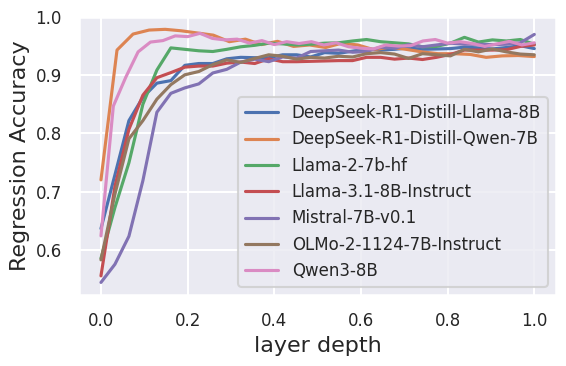

In [11]:
# Plot layer-wise regression accuracy for log-ratio regression probes
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

mpl.rcParams['lines.markersize'] = 2
plt.figure(figsize=(6, 4))

metric = 'val_acc'
metric_title = 'Regression Accuracy'
sns.set_style("darkgrid")
for llm in LLMS:
    name = llm['name']
    pretty = llm['pretty']
    num_layers = llm['num_layers']
    data = regression_diff_probe_results[name]
    
    if data is None:
        continue
        
    layers = range(num_layers)
    norm_layers = [i / (num_layers - 1) for i in layers]
    values = [data[layer][metric] for layer in layers]
    

    sns.lineplot(x=norm_layers[:len(values)],
                 y=values,
                 label=pretty)
    # save the subplot

    plt.xlabel('layer depth')
    plt.ylabel(metric_title)
    plt.legend()

print(f'Probe Metrics Across Layers: {PROBE_SETTING} (log-ratio regression, {OFFSET_REGRESSION})')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_FIG_PATH, "layerwise", PROBE_SETTING, f'log_ratio_regression_{OFFSET_REGRESSION_DIFF}_acc.pdf'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(SAVE_FIG_PATH, "layerwise", PROBE_SETTING, f'log_ratio_regression_{OFFSET_REGRESSION_DIFF}_acc.png'), dpi=300, bbox_inches='tight')
plt.show()


### 3.2 Log-ratio regression correlation: verbalization accuracy vs. probe metrics (max/mean/first/mean first 3/last)

Correlation: Verbalization Acc vs. Mean_first_3 Probe Metrics: int_sci_compare (log-ratio regression, last_token)


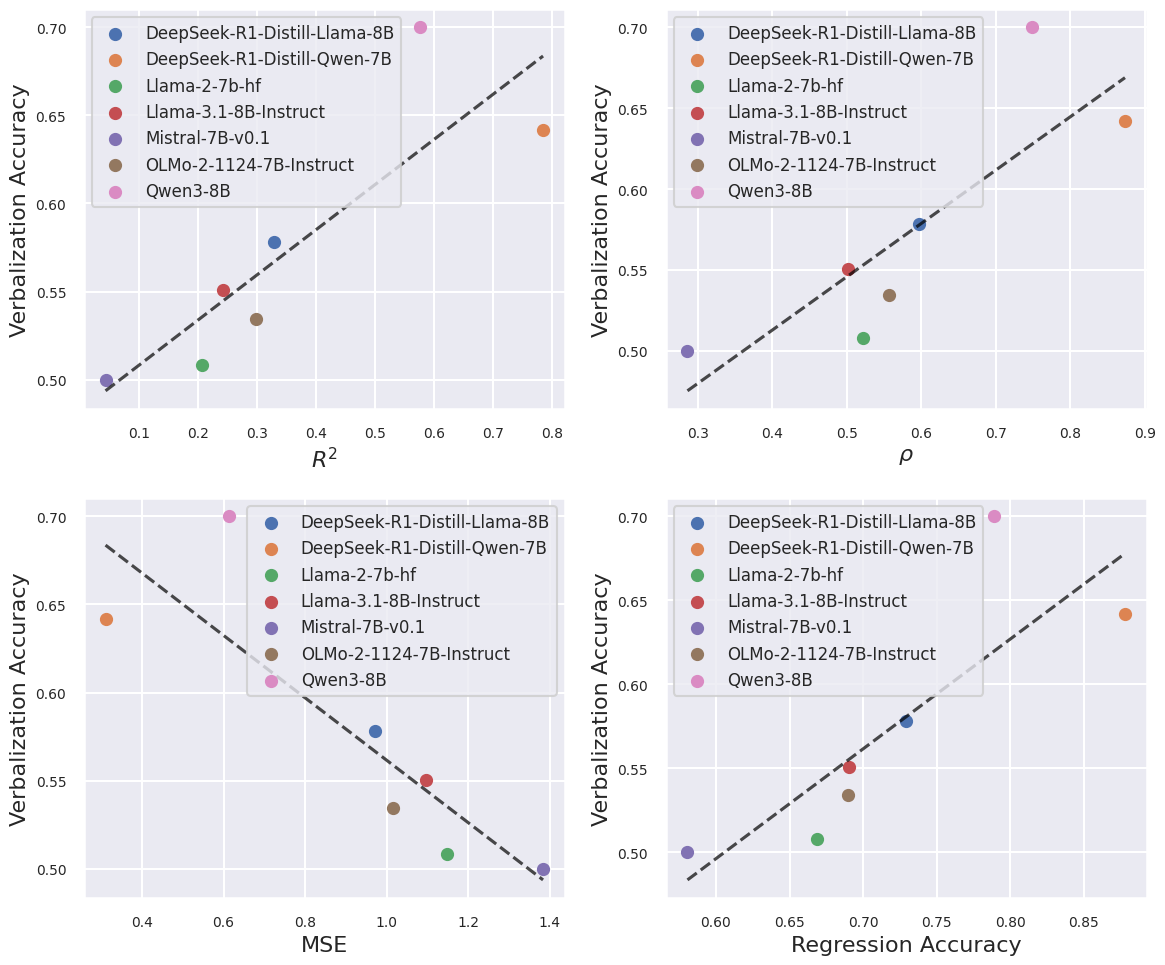

In [12]:
# summary_types = ['max', 'mean', 'first', 'mean_first_3', 'last']
summary_types = ['mean_first_3']
LOG_RATIO_REGRESSION_METRICS = [f'{SPLIT}_{metric}' for metric in ['r2', 'pearson', 'mse', 'acc']]
LOG_RATIO_REGRESSION_METRIC_TITLES = [r'$R^2$', r'$\rho$', 'MSE', 'Regression Accuracy']

sns.set_theme(style="darkgrid", context="talk")
mpl.rcParams['lines.markersize'] = 8
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 10
for summary_type in summary_types:
    plt.figure(figsize=(12, 10))
    
    for i, metric in enumerate(LOG_RATIO_REGRESSION_METRICS):
        plt.subplot(2, 2, i+1)
        x_data, y_data, labels = [], [], []
        
        for llm in LLMS:
            name = llm['name']
            pretty = llm['pretty']
            num_layers = llm['num_layers']
            data = regression_diff_probe_results[name]
            v_acc = verbalization_accs[name]
            
            if data is None or v_acc is None:
                continue
                
            values = [data[layer][metric] for layer in range(num_layers)]
            if not values: 
                continue
            
            # Calculate summary statistic
            if summary_type == 'max':
                val = max(values)
            elif summary_type == 'mean':
                val = np.mean(values)
            elif summary_type == 'first':
                val = values[0]
            elif summary_type == 'last':
                val = values[-1]
            elif summary_type == 'mean_first_3':
                val = np.mean(values[:3])
                
            x_data.append(val)
            y_data.append(v_acc)
            labels.append(pretty)
            plt.scatter(val, v_acc, label=pretty)
        
        if not x_data: 
            continue
        
        # Add regression line
        z = np.polyfit(x_data, y_data, 1)
        p = np.poly1d(z)
        x_range = np.linspace(min(x_data), max(x_data), 100)
        plt.plot(x_range, p(x_range), '--', color='black', alpha=0.7)

        plt.xlabel(f"{LOG_RATIO_REGRESSION_METRIC_TITLES[i]}")
        plt.ylabel("Verbalization Accuracy")
        # plt.title(titles[i])
        plt.grid(True)
        plt.legend()
    
    print(f'Correlation: Verbalization Acc vs. {summary_type.capitalize()} Probe Metrics: {PROBE_SETTING} (log-ratio regression, {OFFSET_REGRESSION_DIFF    })')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_FIG_PATH, "correlation", PROBE_SETTING, f'log_ratio_regression_{OFFSET_REGRESSION_DIFF}_{summary_type}.pdf'), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(SAVE_FIG_PATH, "correlation", PROBE_SETTING, f'log_ratio_regression_{OFFSET_REGRESSION_DIFF}_{summary_type}.png'), dpi=300, bbox_inches='tight')
    plt.show()


Correlation: Verbalization Acc vs. Mean_first_3 Probe Metrics: int_sci_compare (log-ratio regression, last_token)


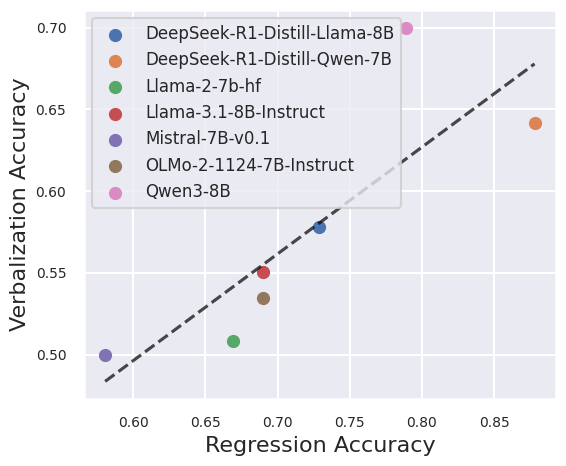

In [13]:
# Plot only log-ratio regression accuracy vs. verbalization accuracy

# summary_types = ['max', 'mean', 'first', 'mean_first_3', 'last']
summary_types = ['mean_first_3']
metric = f'{SPLIT}_acc'
title = 'Regression Accuracy'
sns.set_theme(style="darkgrid", context="talk")
mpl.rcParams['lines.markersize'] = 8
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 10
plt.figure(figsize=(6, 5))
x_data, y_data, labels = [], [], []

for summary_type in summary_types:
    for llm in LLMS:
        name = llm['name']
        pretty = llm['pretty']
        num_layers = llm['num_layers']
        data = regression_diff_probe_results[name]
        v_acc = verbalization_accs[name]
        
        if data is None or v_acc is None:
            continue
            
        values = [data[layer][metric] for layer in range(num_layers)]
        if not values: 
            continue
        
        # Calculate summary statistic
        if summary_type == 'max':
            val = max(values)
        elif summary_type == 'mean':
            val = np.mean(values)
        elif summary_type == 'first':
            val = values[0]
        elif summary_type == 'last':
            val = values[-1]
        elif summary_type == 'mean_first_3':
            val = np.mean(values[:3])
            
        x_data.append(val)
        y_data.append(v_acc)
        labels.append(pretty)
        plt.scatter(val, v_acc, label=pretty)

    # Add regression line
    z = np.polyfit(x_data, y_data, 1)
    p = np.poly1d(z)
    x_range = np.linspace(min(x_data), max(x_data), 100)
    plt.plot(x_range, p(x_range), '--', color='black', alpha=0.7)

    plt.xlabel(f"{title}")
    plt.ylabel("Verbalization Accuracy")
    plt.grid(True)
    plt.legend()
        
    print(f'Correlation: Verbalization Acc vs. {summary_type.capitalize()} Probe Metrics: {PROBE_SETTING} (log-ratio regression, {OFFSET_REGRESSION_DIFF})')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_FIG_PATH, "correlation", PROBE_SETTING, f'log_ratio_regression_{OFFSET_REGRESSION_DIFF}_{summary_type}_{metric}.pdf'), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(SAVE_FIG_PATH, "correlation", PROBE_SETTING, f'log_ratio_regression_{OFFSET_REGRESSION_DIFF}_{summary_type}_{metric}.png'), dpi=300, bbox_inches='tight')
    plt.show()
